In [43]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Your Name and PRN:
- Name: ______________________
- PRN : ______________________
- Date: ______________________

# Deep Neural Network
## Assignment A05

## Tensor Flow
- Select number of layers
- Select node in each of the layers
- Choose activation function
- multi-class - Fashion MNIST dataset (all 60000 images)
- Implement one or more of following to achieve max accuracy.
    - L1/ L2 Regularization
    - Dropout
    - Batch Normalization
    - Early stopping
- Save model

In [44]:
###-----------------
### Import Libraries
###-----------------
import os
import time
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report,confusion_matrix,ConfusionMatrixDisplay
from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix


In [45]:
###-----------------
### Global Variables
###-----------------
inpDir = os.path.join('input')
outDir = '../output'
modelDir = '../models'
subDir = 'fashion_mnist'
altName = 'vanilla'

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
np.random.seed(RANDOM_STATE) # Set Random Seed for reproducible results
tf.random.set_seed(RANDOM_STATE)

# parameters for Matplotlib
params = {'legend.fontsize': 'large',
          'figure.figsize': (15, 8),
          'axes.labelsize': 'large',
          'axes.titlesize':'x-large',
          'xtick.labelsize':'large',
          'ytick.labelsize':'large'
         }

CMAP = 'brg' # plt.cm.Spectral

plt.rcParams.update(params)


In [46]:
###-----------------
### Hyper Parameters
###-----------------


BATCH_SIZE = 32 # mini batch size (number of rows)
TRAIN_SIZE  = int(18*BATCH_SIZE)
TEST_SIZE = 0.2

ALPHA = 0.001
EPOCHS = 100 # number of epochs
WEIGHT_DECAY = 0.001
PATIENCE = 20
LR_FACTOR  = 0.1
LR_PATIENCE = 5
MIN_LR = 1e-5

params = {'legend.fontsize': 'medium',
          'figure.figsize': (15, 5),
          'axes.labelsize': 'large',
          'axes.titlesize':'large',
          'xtick.labelsize':'medium',
          'ytick.labelsize':'medium'
         }


## Load Fashion MNIST dataset

This guide uses the [Fashion MNIST](https://github.com/zalandoresearch/fashion-mnist) dataset which contains 70,000 grayscale images in 10 categories. The images show individual articles of clothing at low resolution (28 by 28 pixels), as seen here:

<table>
  <tr><td>
    <img src="https://tensorflow.org/images/fashion-mnist-sprite.png"
         alt="Fashion MNIST sprite"  width="600">
  </td></tr>
  <tr><td align="center">
    <b>Figure 1.</b> <a href="https://github.com/zalandoresearch/fashion-mnist">Fashion-MNIST samples</a> (by Zalando, MIT License).<br/>&nbsp;
  </td></tr>
</table>

Fashion MNIST is intended as a drop-in replacement for the classic [MNIST](http://yann.lecun.com/exdb/mnist/) dataset—often used as the "Hello, World" of machine learning programs for computer vision. The MNIST dataset contains images of handwritten digits (0, 1, 2, etc.) in a format identical to that of the articles of clothing you'll use here.

This guide uses Fashion MNIST for variety, and because it's a slightly more challenging problem than regular MNIST. Both datasets are relatively small and are used to verify that an algorithm works as expected. They're good starting points to test and debug code.

Here, 60,000 images are used to train the network and 10,000 images to evaluate how accurately the network learned to classify images. You can access the Fashion MNIST directly from TensorFlow. Import and [load the Fashion MNIST data](https://www.tensorflow.org/api_docs/python/tf/keras/datasets/fashion_mnist/load_data) directly from TensorFlow:

In [47]:

train_df = pd.read_csv('fashion-mnist_train.csv',header = 0)
test_df = pd.read_csv('fashion-mnist_test.csv',header = 0)

<table>
  <tr>
    <th>Label</th>
    <th>Class</th>
  </tr>
  <tr>
    <td>0</td>
    <td>T-shirt/top</td>
  </tr>
  <tr>
    <td>1</td>
    <td>Trouser</td>
  </tr>
    <tr>
    <td>2</td>
    <td>Pullover</td>
  </tr>
    <tr>
    <td>3</td>
    <td>Dress</td>
  </tr>
    <tr>
    <td>4</td>
    <td>Coat</td>
  </tr>
    <tr>
    <td>5</td>
    <td>Sandal</td>
  </tr>
    <tr>
    <td>6</td>
    <td>Shirt</td>
  </tr>
    <tr>
    <td>7</td>
    <td>Sneaker</td>
  </tr>
    <tr>
    <td>8</td>
    <td>Bag</td>
  </tr>
    <tr>
    <td>9</td>
    <td>Ankle boot</td>
  </tr>
</table>

Each image is mapped to a single label. Since the *class names* are not included with the dataset, store them here to use later when plotting the images:

In [48]:
#class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
#               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

class_names = {0: 'T-shirt/top',1:'Trouser',2:'Pullover',3:'Dress',4:'Coat',
               5:'Sandal', 6: 'Shirt',7: 'Sneaker', 8:'Bag', 9: 'Ankle boot'}

In [49]:
def fn_plt_label(tr_df,ts_df):
    plt.figure()
    plt.subplot(1,2,1)
    ax = tr_df['label'].value_counts().plot(kind = 'bar',
                                          title = 'Train',
                                          color = 'Darkblue',
                                          alpha = 0.7)
    plt.subplot(1,2,2)

    ax = ts_df['label'].value_counts().plot(kind = 'bar',
                                          title = 'Test',
                                          color = 'Orange',
                                          alpha = 0.7)

In [50]:
# fn_plt_label(train_df,test_df)

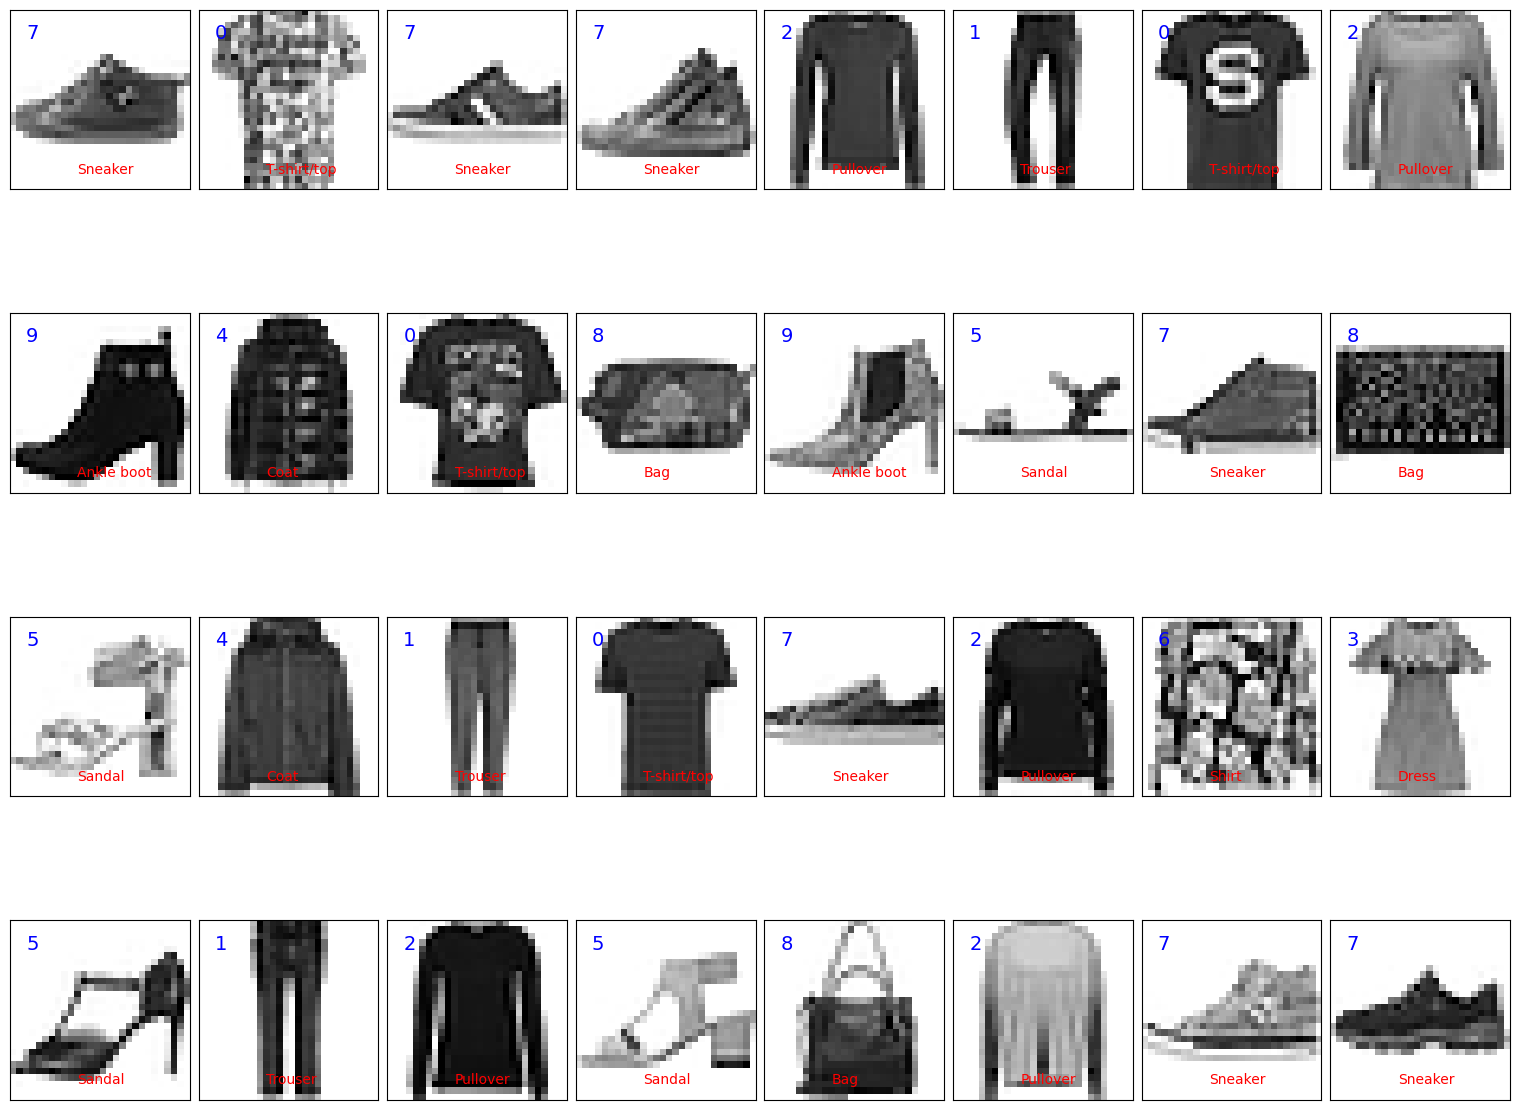

In [51]:
# sample data plot

plot_df = train_df.sample(n=BATCH_SIZE) # take 100 sample from the training set
fig = plt.figure(figsize=(15, 12)) # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust

i = 0
for _, row in plot_df.iterrows(): # iterate through all rows of the dataframe
    i = i + 1
    image = row.values[1:].reshape(28, 28) # reshape row to a 28 x 28 matrix
    ax = fig.add_subplot(BATCH_SIZE//8, 8, (i), xticks=[], yticks=[])
    ax.imshow(image, cmap=plt.cm.binary, interpolation='nearest')
    ax.text(2, 4, str(row.iloc[0]), color='b', fontsize=14)
    ax.text(10, 25, class_names[row.iloc[0]], color='r', fontsize=10)

plt.show()

In [52]:
def split_features_label(row):
    feature = tf.reshape(row[1:],[28,28,1])
    label = row[0]
    return feature,label


<h1>Plotting dataset</h1>

In [53]:
tmp_ds = tf.data.Dataset.from_tensor_slices(train_df)
train_ds = tmp_ds.map(split_features_label)
train_ds = train_ds.batch(batch_size=BATCH_SIZE)

tmp_ds = tf.data.Dataset.from_tensor_slices(test_df)
test_ds = tmp_ds.map(split_features_label)
test_ds = test_ds.batch(batch_size=BATCH_SIZE)

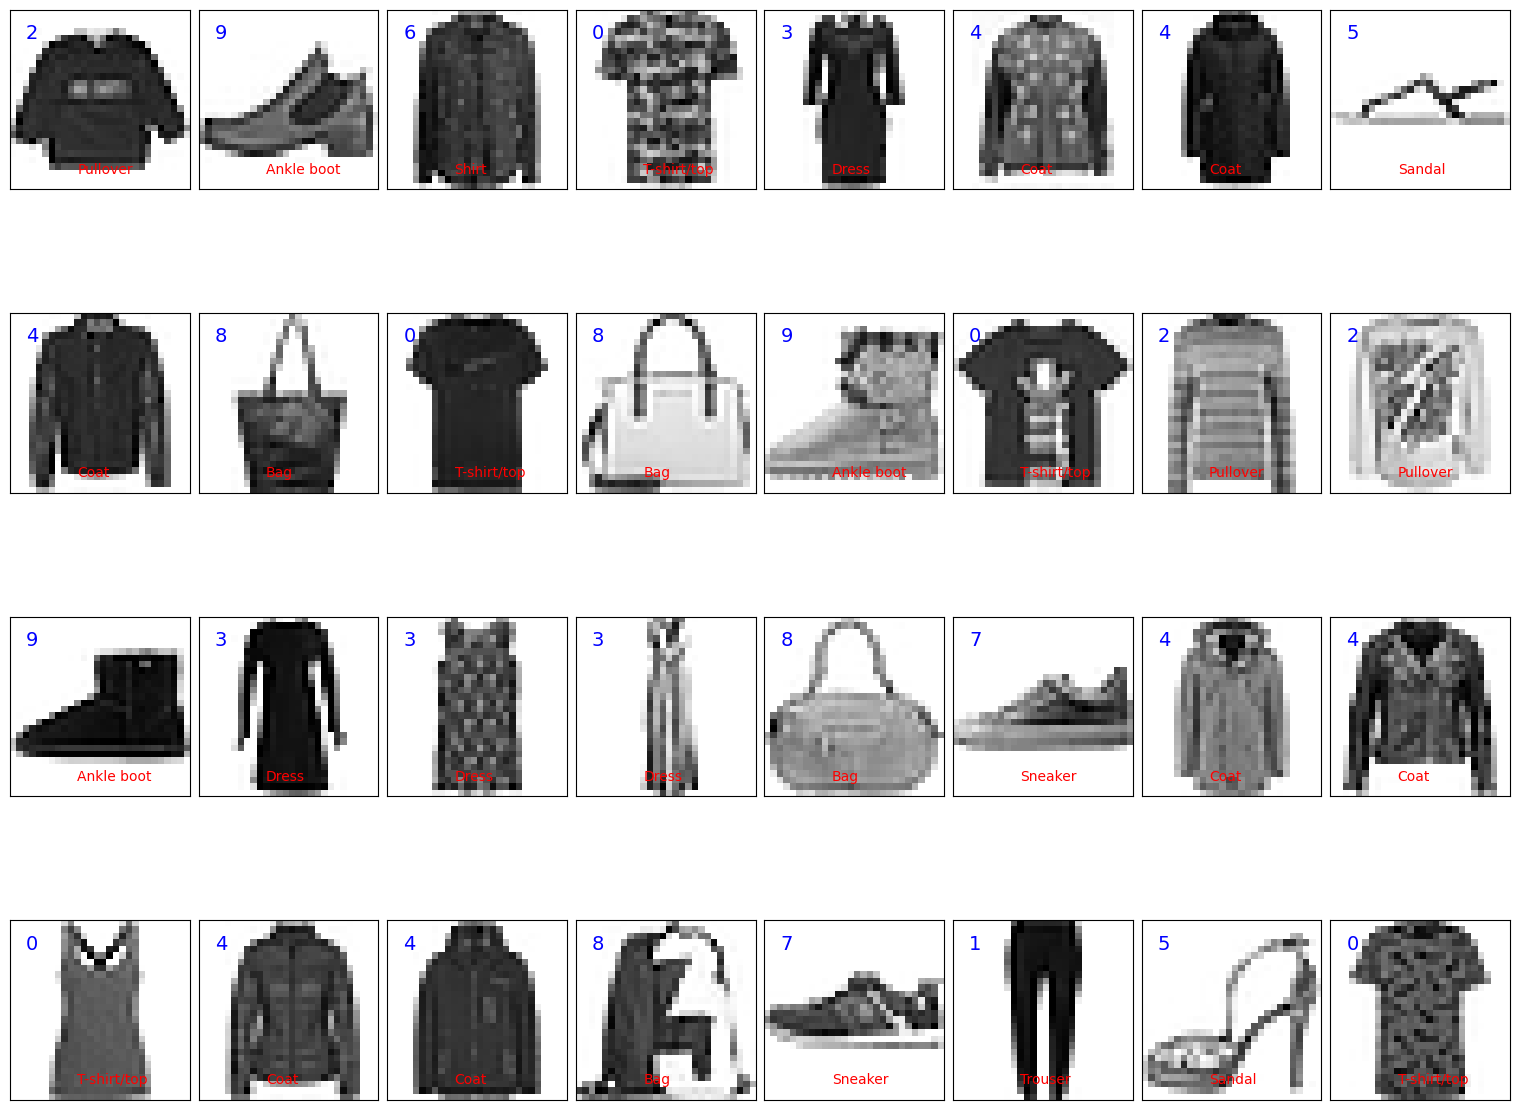

In [54]:
# sample data plot

# plot_df = train_df.sample(n=BATCH_SIZE) # take 100 sample from the training set
fig = plt.figure(figsize=(15, 12)) # figure size in inches
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust

i = 0
for images,labels in train_ds.take(1):
    for i in range(BATCH_SIZE): # iterate through all rows of the dataframe
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary)
        ax.text(2, 4, str(labels[i].numpy()), color='b', fontsize=14)
        ax.text(10, 25, class_names[labels[i].numpy()], color='r', fontsize=10)

plt.show()

<h1>rescaling</h1>

In [55]:
norm_layer = tf.keras.layers.Rescaling(1.0/255)
print(f'{images[0].numpy().min(),images[0].numpy().max()}')

norm_ds = train_ds.map(lambda x,y : (norm_layer(x),y))
images,lables = next(iter(norm_ds))
print(f'{images[0].numpy().min(),images[0].numpy().max()}')


(np.int64(0), np.int64(255))
(np.float32(0.0), np.float32(1.0))


<h1>Convulation in action</h1>

<Axes: >

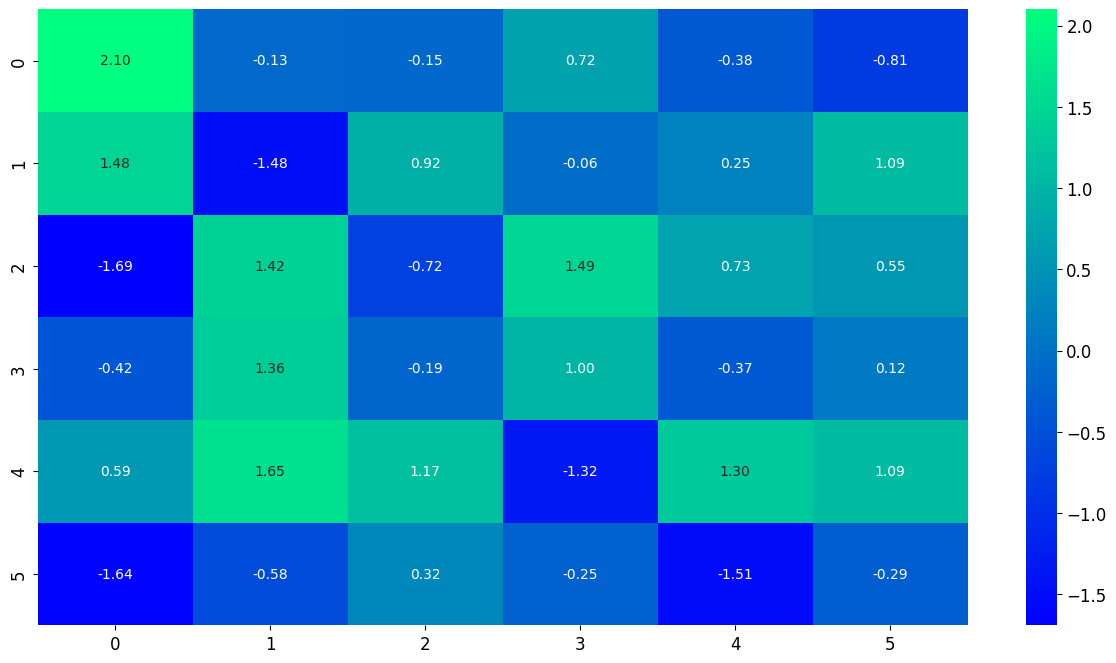

In [56]:
input_shape = (1,6,6,1)
X = tf.random.normal(input_shape)
X.shape
sns.heatmap(X.numpy()[0,:,:,0],annot = True,fmt = '.2f', cmap = 'winter')

In [57]:
y = tf.keras.layers.Conv2D(
                           1,3,
                           kernel_initializer=tf.constant_initializer(1.0),
                           use_bias = False,
                           activation = 'relu'
                          )(X)
y.shape

TensorShape([1, 4, 4, 1])

<Axes: >

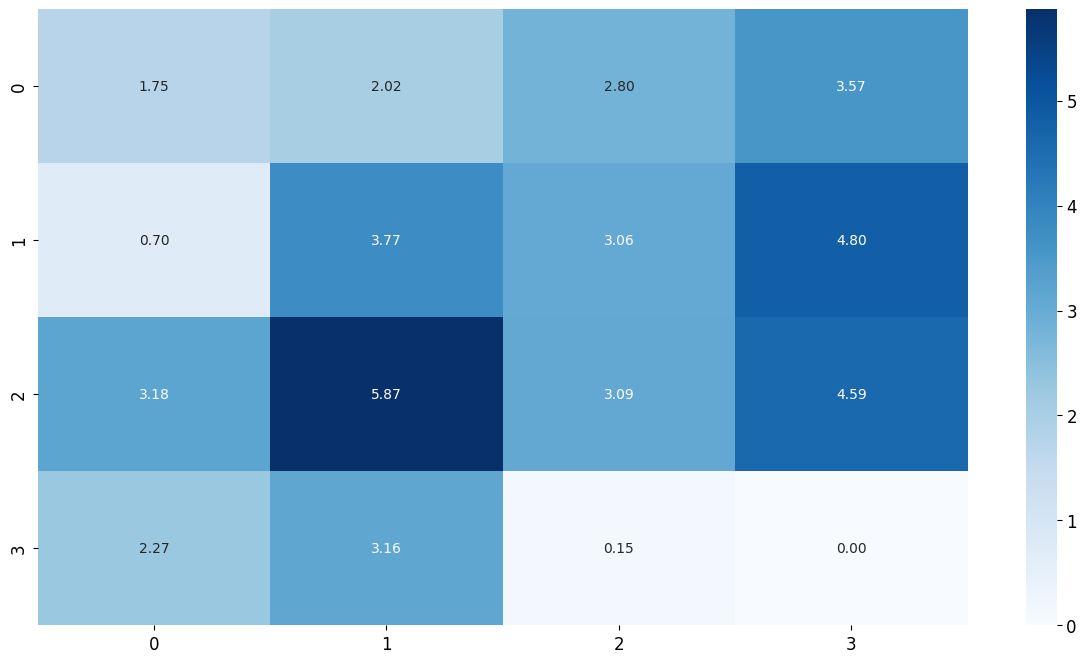

In [58]:

sns.heatmap(y.numpy()[0,:,:,0],
            annot = True,
            fmt = '.2f',
            cmap = 'Blues')

<Axes: >

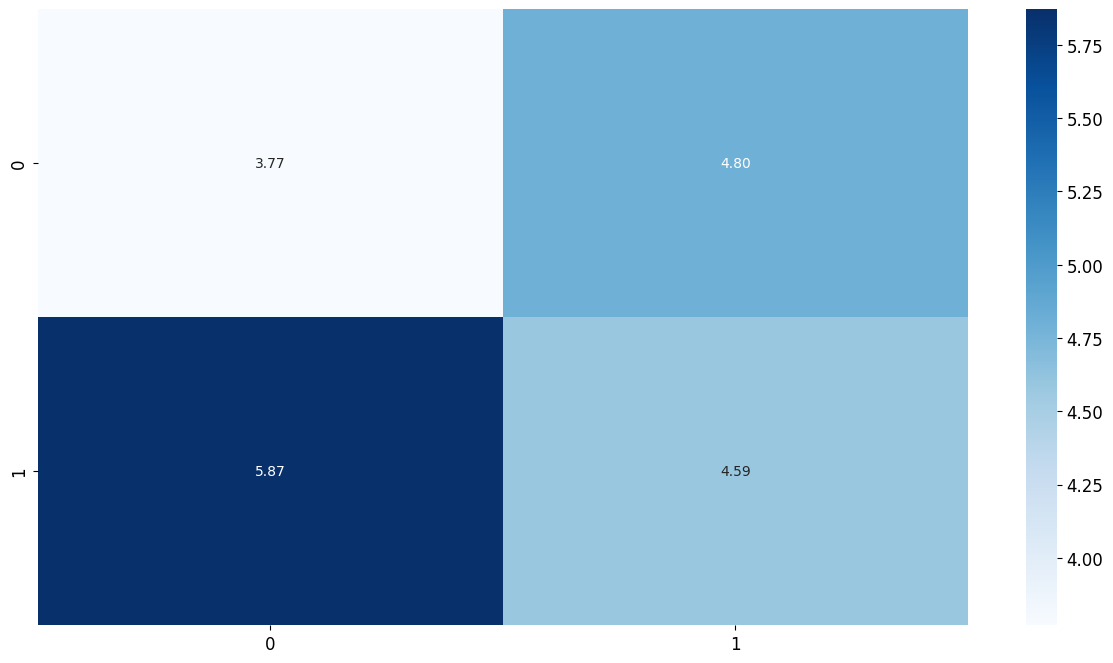

In [59]:
max_pool_2d = tf.keras.layers.MaxPool2D()(y)

sns.heatmap(max_pool_2d.numpy()[0,:,:,0],
            annot = True,
            fmt = '.2f',
            cmap = 'Blues')


<h1>Build model </h1>

In [60]:
input_shape = (28,28,1)

regularizer = tf.keras.regularizers.L2(l2 = 0.001)
dor1 = 0.1
dor2 = 0.2
dor3 = 0.3
dor4 = 0.4




model = tf.keras.Sequential()
model.add(tf.keras.Input(shape=input_shape))
model.add(tf.keras.layers.Rescaling(1.0/255))

#Set 1
model.add(tf.keras.layers.Conv2D(32,(3,3),padding='same',
                                 # kernel_regularizer=regularizer,
                                 # activation='relu'
                                )) #(28 * 28 * 32)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D()) #(14*14*32)
model.add(tf.keras.layers.Dropout(dor1))

#Set 2
model.add(tf.keras.layers.Conv2D(64,(3,3),padding='same',
                                 # kernel_regularizer=regularizer,
                                 # activation='relu'
                                )) #(12 * 12 * 64)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.MaxPool2D()) #(14*14*32)
model.add(tf.keras.layers.Dropout(dor2))

#Set 3
model.add(tf.keras.layers.Conv2D(128,(3,3),padding='same',
                                 # kernel_regularizer=regularizer,
                                 # activation='relu'
                                )) #(4 * 4 * 128)
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.Dropout(dor3))

model.add(tf.keras.layers.Flatten())


model.add(tf.keras.layers.Dense(128,
                                # kernel_regularizer=regularizer,
                                # activation='relu'
                               ))
model.add(tf.keras.layers.BatchNormalization())
model.add(tf.keras.layers.ReLU())
model.add(tf.keras.layers.Dropout(dor4))

model.add(tf.keras.layers.Dense(10))


loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
optimizer = tf.keras.optimizers.Adam(learning_rate = ALPHA)
model.compile(optimizer = optimizer,
             loss = loss_fn,

             metrics = ['accuracy'])

In [61]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_4 (Rescaling)         │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 6272)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       802,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 898,314 (3.43 MB)

 Trainable params: 897,610 (3.42 MB)

 Non-trainable params: 704 (2.75 KB)

In [62]:
#call backs

tb_callback = tf.keras .callbacks.TensorBoard(log_dir='logs')

es_callback = tf.keras.callbacks.EarlyStopping(monitor= 'val_loss',
                                               min_delta= 0,
                                              patience=PATIENCE,
                                              verbose = 1,
                                              restore_best_weights=True,
)

lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
   monitor='val_loss',
    factor= LR_FACTOR,
    patience = LR_PATIENCE,
    verbose = 1,
    min_lr=1e-6
)



In [63]:
history = model.fit(train_ds,
         validation_data=test_ds,
         epochs= EPOCHS,
         callbacks=[es_callback,lr_callback])

Epoch 1/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 19s 6ms/step - accuracy: 0.7983 - loss: 0.5675 - val_accuracy: 0.9015 - val_loss: 0.2661 - learning_rate: 0.0010
Epoch 2/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8817 - loss: 0.3259 - val_accuracy: 0.9114 - val_loss: 0.2343 - learning_rate: 0.0010
Epoch 3/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.8950 - loss: 0.2881 - val_accuracy: 0.9167 - val_loss: 0.2224 - learning_rate: 0.0010
Epoch 4/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9051 - loss: 0.2618 - val_accuracy: 0.9130 - val_loss: 0.2309 - learning_rate: 0.0010
Epoch 5/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9091 - loss: 0.2459 - val_accuracy: 0.9122 - val_loss: 0.2371 - learning_rate: 0.0010
Epoch 6/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9152 - loss: 0.2295 - val_accuracy: 0.9264 - val_loss: 0.2022 - learning_rate: 0.0010
Epoch 7/100
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 

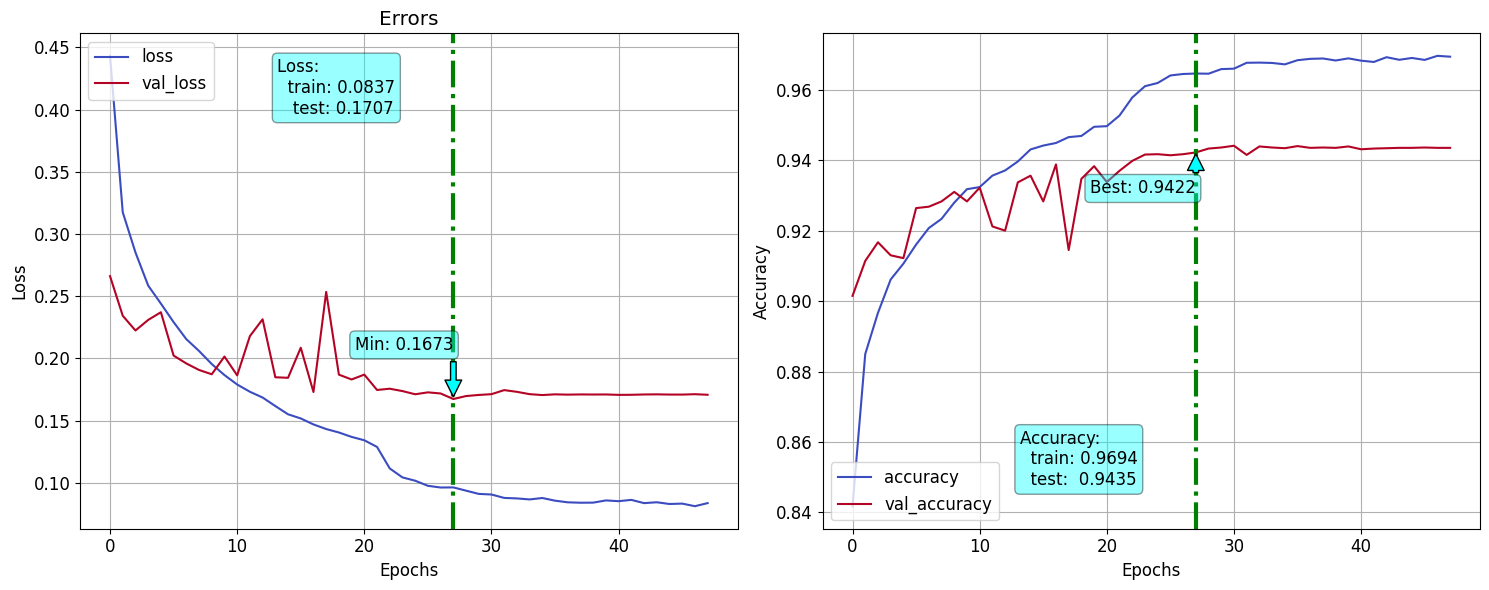

In [64]:
loss_df = pd.DataFrame(history.history)
fn_plot_tf_hist(loss_df)

In [1]:
y_train = tf.concat([y for x, y in train_ds], axis=0).numpy()
print(y_train.shape)

NameError: name 'tf' is not defined

In [66]:
yhat = model.predict(train_ds)
y_pred = yhat.argmax(axis=1)
print(f'Accuracy: {accuracy_score(y_train, y_pred):.5f}')
print(classification_report(y_train, y_pred))

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step
Accuracy: 0.98415
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      6000
           1       1.00      1.00      1.00      6000
           2       0.97      0.98      0.97      6000
           3       0.98      0.99      0.99      6000
           4       0.97      0.98      0.98      6000
           5       1.00      1.00      1.00      6000
           6       0.96      0.94      0.95      6000
           7       0.99      1.00      0.99      6000
           8       1.00      1.00      1.00      6000
           9       1.00      0.99      0.99      6000

    accuracy                           0.98     60000
   macro avg       0.98      0.98      0.98     60000
weighted avg       0.98      0.98      0.98     60000



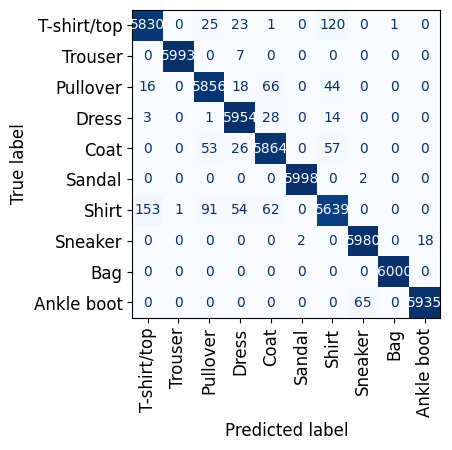

In [67]:
fn_plot_confusion_matrix(y_train, y_pred, class_names)

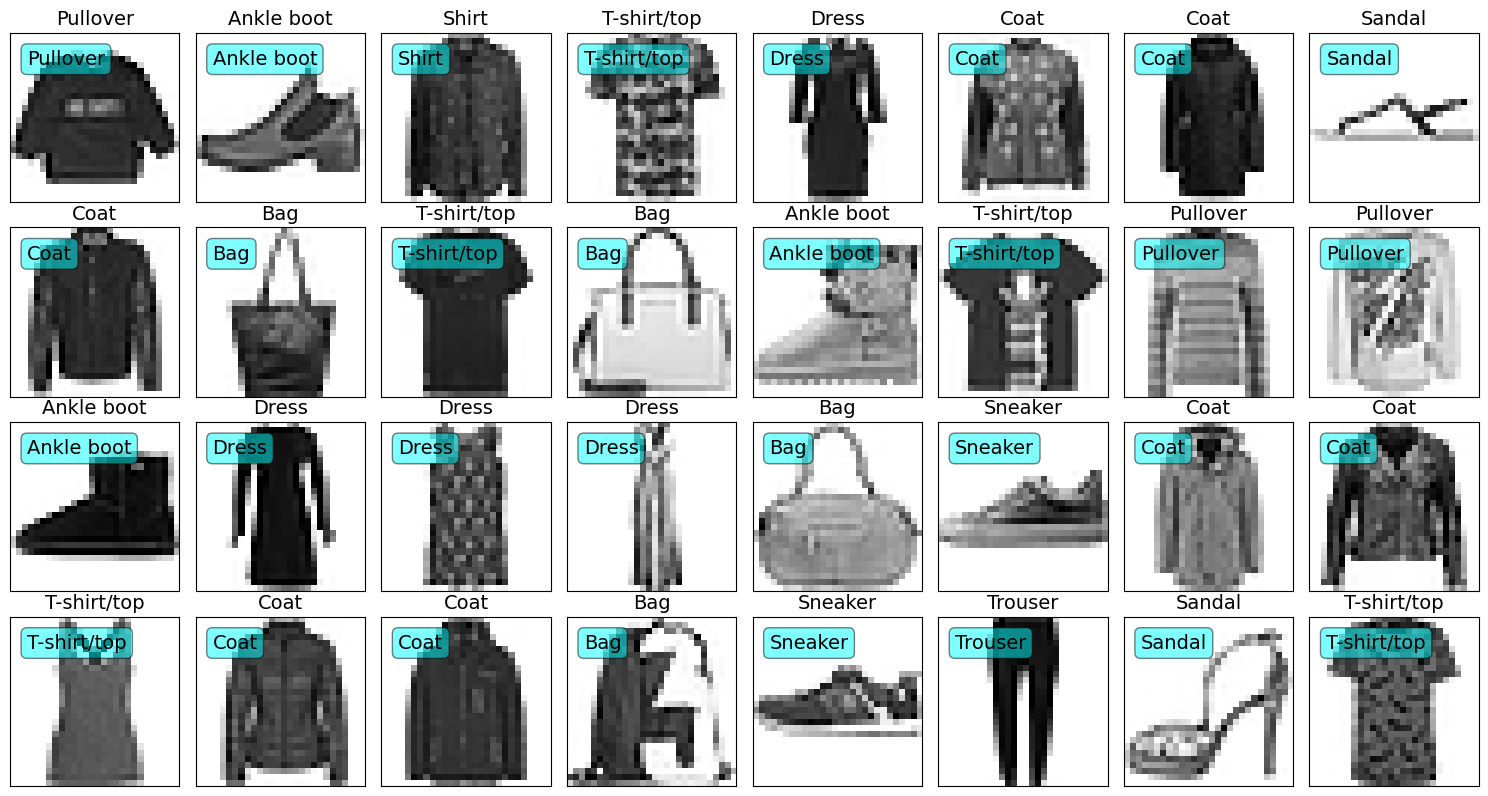

In [68]:
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for images, labels in train_ds.take(1):
    yhat = model(images).numpy()
    y_pred = yhat.argmax(axis=1)
    for i in range(BATCH_SIZE):
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        color = 'cyan'
        if y_pred[i] != labels[i]:
            color = 'red'
        props = dict(boxstyle = 'round',facecolor = color,alpha = 0.5)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
        # ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
        # ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
        ax.text(0.1,0.90,class_names[y_pred[i]],bbox = props,
               verticalalignment = 'top',
               transform = ax.transAxes,fontsize = 14)
        ax.set_title(class_names[labels[i].numpy()],fontsize = 14)
plt.tight_layout()
plt.show()

In [69]:
y_test = tf.concat([y for x, y in test_ds], axis=0).numpy()
print(y_test.shape)

(10000,)


In [70]:
yhat = model.predict(test_ds)
y_pred = yhat.argmax(axis=1)
print(f'Accuracy: {accuracy_score(y_test, y_pred):.5f}')
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy: 0.94220
              precision    recall  f1-score   support

           0       0.89      0.90      0.89      1000
           1       1.00      1.00      1.00      1000
           2       0.93      0.90      0.91      1000
           3       0.94      0.96      0.95      1000
           4       0.92      0.92      0.92      1000
           5       0.99      0.98      0.99      1000
           6       0.83      0.82      0.83      1000
           7       0.96      0.98      0.97      1000
           8       1.00      0.99      0.99      1000
           9       0.97      0.97      0.97      1000

    accuracy                           0.94     10000
   macro avg       0.94      0.94      0.94     10000
weighted avg       0.94      0.94      0.94     10000



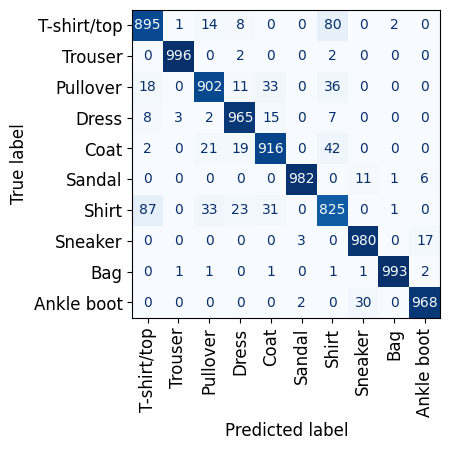

In [71]:
fn_plot_confusion_matrix(y_test, y_pred, class_names)

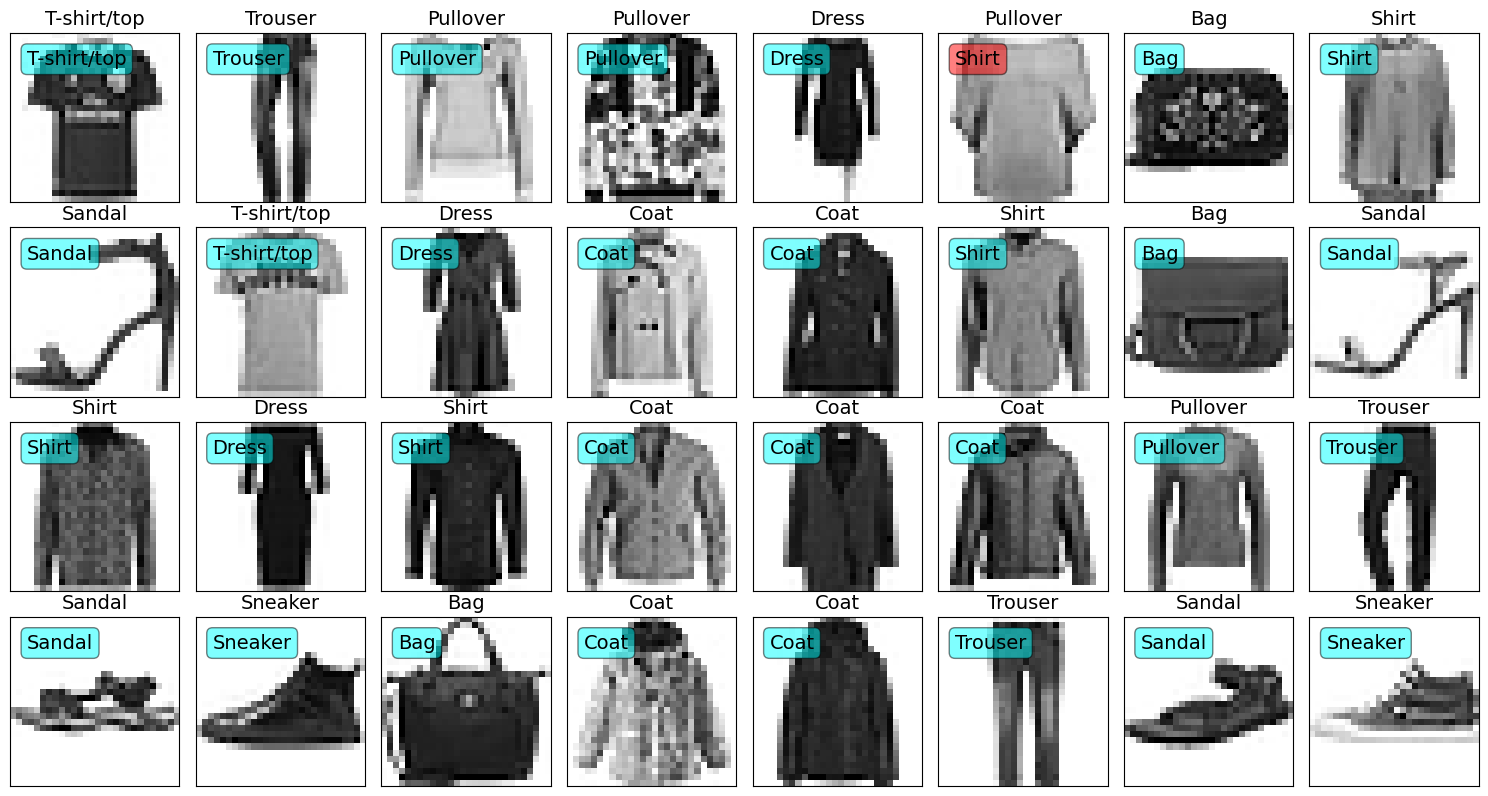

In [72]:
fig = plt.figure()
fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

i=0
for images, labels in test_ds.take(1):
    yhat = model(images).numpy()
    y_pred = yhat.argmax(axis=1)
    for i in range(BATCH_SIZE):
        ax = fig.add_subplot(BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[])
        ax.grid(False)
        color = 'cyan'
        if y_pred[i] != labels[i]:
            color = 'red'
        props = dict(boxstyle = 'round',facecolor = color,alpha = 0.5)
        ax.imshow(images[i].numpy().astype('uint8'), cmap=plt.cm.binary, interpolation='nearest')
        # ax.text(2,4, str(labels[i].numpy()), color='b', fontsize=14)
        # ax.text(10,25, class_names[labels[i].numpy()], color='r', fontsize=10)
        ax.text(0.1,0.90,class_names[y_pred[i]],bbox = props,
               verticalalignment = 'top',
               transform = ax.transAxes,fontsize = 14)
        ax.set_title(class_names[labels[i].numpy()],fontsize = 14)
plt.tight_layout()
plt.show()

<h1>Make Prediction</h1>

In [73]:
yhat = model.predict(train_ds)
y_pred = yhat.argmax(axis = 1)
print(f'Accuracy : {accuracy_score(y_train,y_predf}')
print(classification_report(y_train,y_pred))

SyntaxError: closing parenthesis '}' does not match opening parenthesis '(' (ipython-input-3047930411.py, line 3)